# Бифуркационный анализ модели химической кинетики

## Однопараметрический анализ модели

Исследуем зависимость стационарных состояний и их устойчивости от параметра \(k_1\) при фиксированном \(k_2\)

### Задаём модель и параметры

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import symbols, sqrt, diff, Matrix, lambdify, solve
import warnings
warnings.filterwarnings('ignore')

class ChemicalModel:
    """Модель c автоматическим вычислением Якобиана"""
    def __init__(self):
        # Определение символов
        self.x, self.y = symbols('x y')
        self.k1, self.k1m, self.k2, self.k3, self.k3m = symbols('k1 k1m k2 k3 k3m')
        
        # Стационарное состояние
        self.z = 1 - self.x - self.y
        
        # Уравнения модели
        self.dxdt = self.k1 * self.z - self.k1m * self.x - self.k2 * self.z**2 * self.x
        self.dydt = self.k3 * self.z**2 - self.k3m * self.y**2
        
        self.f = [self.dxdt, self.dydt]
        
        # Матрица Якоби
        self.J = Matrix([
            [diff(self.dxdt, self.x), diff(self.dxdt, self.y)],
            [diff(self.dydt, self.x), diff(self.dydt, self.y)]
        ])
        
        # Базовые параметры
        self.params_base = {
            self.k1: 0.12,
            self.k1m: 0.005,
            self.k3: 0.0032,
            self.k3m: 0.002,
            self.k2: 1.05
        }

        self._create_numeric_functions()
    
    def _create_numeric_functions(self):
        """Создание численных функций из символьных выражений для производительности"""
        symbols_list = [self.x, self.y, self.k1, self.k1m, self.k2, self.k3, self.k3m]

        self.jac_num = lambdify(symbols_list, self.J, modules='numpy')
    
    def get_steady_state_expressions(self):
        """
        Аналитическое выражение для стационарного состояния
        Решаем систему f = 0
        """
        # k3*z^2 - k3m*y^2 = 0
        sqrt_ratio = sqrt(self.k3m/self.k3)
        y_expr = (1 - self.x) / (1 + sqrt_ratio)
        z_expr = 1 - self.x - y_expr
        
        # Из dx/dt = 0 выражаем k1
        k1_expr = (self.k1m * self.x + self.k2 * self.x * z_expr**2) / z_expr
        
        return y_expr, z_expr, k1_expr
    
    def get_jacobian_at_point(self, x_val, y_val, k1_val, k2_val=None, k1m_val=None, k3_val=None, k3m_val=None):
        """
        Получение численной матрицы Якоби в заданной точке
        """
        # Используем базовые значения, если не указаны
        if k1m_val is None:
            k1m_val = self.params_base[self.k1m]
        if k2_val is None:
            k2_val = self.params_base[self.k1m]
        if k3_val is None:
            k3_val = self.params_base[self.k3]
        if k3m_val is None:
            k3m_val = self.params_base[self.k3m]

        jac_numeric = self.jac_num(
            x_val, y_val,
            k1_val, k1m_val,
            k2_val,          
            k3_val, k3m_val  
        )
        
        return jac_numeric
    
    def compute_trace_and_det(self, x_val, y_val, k1_val, k2_val):
        """
        Вычисление следа и определителя матрицы Якоби
        """
        jac = self.get_jacobian_at_point(x_val, y_val, k1_val, k2_val)
        trace = np.trace(jac)
        det = np.linalg.det(jac)
        return trace, det

### Первый этап: поиск точек бифуркаций


Результаты однопараметрического анализа при k2 = 1.02
Найдено Hopf-бифуркаций: 2
  Hopf 1: k1 = 0.106772, x = 0.340000, y = 0.368598
  Hopf 2: k1 = 0.118362, x = 0.825000, y = 0.097734

Найдено седло-узловых бифуркаций: 2
  SN 1: k1 = 0.125395, x = 0.568000, y = 0.241264
  SN 2: k1 = 0.117309, x = 0.793000, y = 0.115606


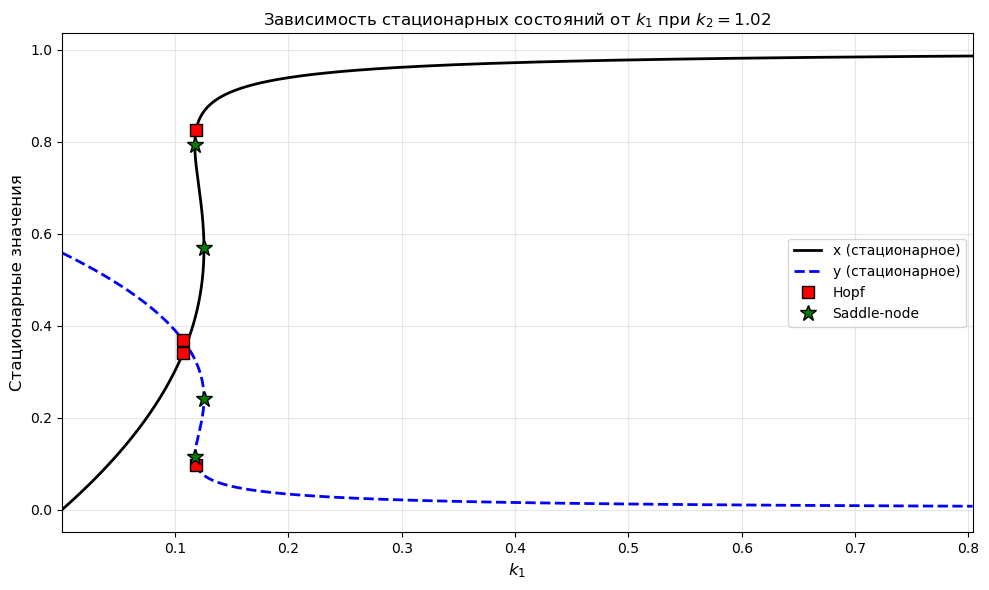

In [8]:
# Инициализация модели
model = ChemicalModel()

# Параметры анализа
k2_fixed = 1.02  # Фиксированное значение k2
x_range = np.arange(0.001, 0.987, 0.001)  # Диапазон изменения x

# Получаем символьные выражения для стационарного состояния
y_expr, z_expr, k1_expr = model.get_steady_state_expressions()

# Создаем численные функции для быстрых вычислений
# Подготавливаем словарь подстановок с базовыми параметрами
subs_dict_base = {
    model.k1m: model.params_base[model.k1m],
    model.k3: model.params_base[model.k3],
    model.k3m: model.params_base[model.k3m]
}

y_func = lambdify([model.x, model.k2], y_expr.subs(subs_dict_base), modules='numpy')
k1_func = lambdify([model.x, model.k2], k1_expr.subs(subs_dict_base), modules='numpy')

# Создаем функцию для вычисления следа и определителя Якобиана
def compute_stability(x_val, k1_val, k2_val):
    """
    Вычисляет след и определитель матрицы Якоби в стационарной точке
    """
    # Вычисляем y и z из стационарного состояния
    y_val = y_func(x_val, k2_val)
    z_val = 1 - x_val - y_val
    
    jac = model.get_jacobian_at_point(
        x_val=x_val,
        y_val=y_val,
        k1_val=k1_val,
        k2_val=k2_val
    )
    
    # След и определитель
    trace = np.trace(jac)
    det = np.linalg.det(jac)
    
    return trace, det, y_val, z_val

n = len(x_range)
k1_values = np.zeros(n)
y_values = np.zeros(n)
trace_values = np.zeros(n)
det_values = np.zeros(n)

for i, x_val in enumerate(x_range):
    # Вычисляем k1 и y для текущего x
    k1_values[i] = k1_func(x_val, k2_fixed)
    y_values[i] = y_func(x_val, k2_fixed)
    
    # Вычисляем след и определитель
    trace, det, _, _ = compute_stability(x_val, k1_values[i], k2_fixed)
    trace_values[i] = trace
    det_values[i] = det


# Поиск бифуркационных точек
hopf_indices = []
saddle_node_indices = []

for i in range(1, n):
    # Hopf бифуркация: смена знака следа
    if trace_values[i] * trace_values[i-1] <= 0 and abs(trace_values[i] - trace_values[i-1]) > 1e-10:
        # Линейная интерполяция для более точного определения
        t1, t2 = trace_values[i-1], trace_values[i]
        k1_1, k1_2 = k1_values[i-1], k1_values[i]
        alpha = abs(t1) / (abs(t1) + abs(t2))
        k1_hopf = k1_1 + alpha * (k1_2 - k1_1)
        hopf_indices.append((i, k1_hopf))
    
    # Седло-узловая бифуркация: смена знака определителя
    if det_values[i] * det_values[i-1] <= 0 and abs(det_values[i] - det_values[i-1]) > 1e-10:
        t1, t2 = det_values[i-1], det_values[i]
        k1_1, k1_2 = k1_values[i-1], k1_values[i]
        alpha = abs(t1) / (abs(t1) + abs(t2))
        k1_sn = k1_1 + alpha * (k1_2 - k1_1)
        saddle_node_indices.append((i, k1_sn))

# Вывод информации о найденных бифуркациях
print(f"\n{'='*50}")
print(f"Результаты однопараметрического анализа при k2 = {k2_fixed}")
print(f"{'='*50}")
print(f"Найдено Hopf-бифуркаций: {len(hopf_indices)}")
for idx, (i, k1_val) in enumerate(hopf_indices):
    print(f"  Hopf {idx+1}: k1 = {k1_val:.6f}, x = {x_range[i]:.6f}, y = {y_values[i]:.6f}")

print(f"\nНайдено седло-узловых бифуркаций: {len(saddle_node_indices)}")
for idx, (i, k1_val) in enumerate(saddle_node_indices):
    print(f"  SN {idx+1}: k1 = {k1_val:.6f}, x = {x_range[i]:.6f}, y = {y_values[i]:.6f}")

# Визуализация результатов

plt.figure(figsize=(10, 6))

# График: Зависимость x и y от k1
plt.plot(k1_values, x_range, 'k-', linewidth=2, label='x (стационарное)')
plt.plot(k1_values, y_values, 'b--', linewidth=2, label='y (стационарное)')

# Отмечаем бифуркации на графике
for idx, (i, k1_val) in enumerate(hopf_indices):
    plt.plot(k1_val, x_range[i], 's', markersize=8, 
             markerfacecolor='red', markeredgecolor='black', 
             label='Hopf' if idx == 0 else "")
    plt.plot(k1_val, y_values[i], 's', markersize=8, 
             markerfacecolor='red', markeredgecolor='black')

for idx, (i, k1_val) in enumerate(saddle_node_indices):
    plt.plot(k1_val, x_range[i], '*', markersize=12, 
             color='green', markeredgecolor='black',
             label='Saddle-node' if idx == 0 else "")
    plt.plot(k1_val, y_values[i], '*', markersize=12, 
             color='green', markeredgecolor='black')

plt.xlabel('$k_1$', fontsize=12)
plt.ylabel('Стационарные значения', fontsize=12)
plt.title(f'Зависимость стационарных состояний от $k_1$ при $k_2 = {k2_fixed}$', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([min(k1_values), max(k1_values)])

plt.tight_layout()
plt.show()

## Двухпараметрический анализ

ДВУХПАРАМЕТРИЧЕСКИЙ АНАЛИЗ (k1m=0.005, k3=0.0032, k3m=0.002)


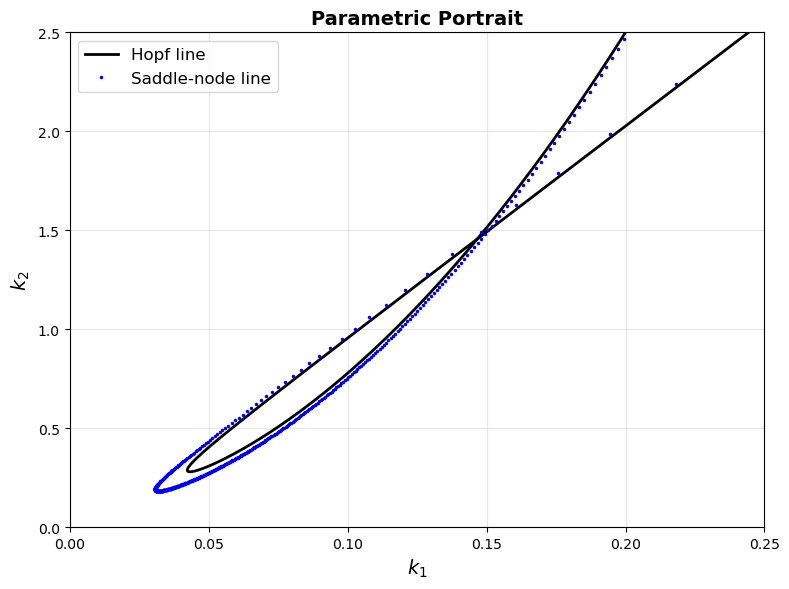

In [ ]:
# Параметры
k1m, k3, k3m = model.params_base[model.k1m], model.params_base[model.k3], model.params_base[model.k3m]
sqrt_ratio = np.sqrt(k3m / k3)
x_vals = np.arange(0.001, 0.987, 0.001)

# Функции для стационарного состояния
def steady_state(x):
    y = (1 - x) / (1 + sqrt_ratio)
    z = 1 - x - y
    return y, z

# Расчет линий бифуркаций
hopf_points = []  # (k1, k2, x)
sn_points = []    # (k1, k2, x)

for x in x_vals:
    y, z = steady_state(x)
    
    # Линия Hopf: trace = 0
    denom_h = x * z**2 - z**3
    if denom_h > 0:
        k2_h = (x * k1m + k1m * z + 2 * k3m * y * z) / denom_h
        if k2_h > 0:
            k1_h = (k1m * x + k2_h * x * z**2) / z
            hopf_points.append((k1_h, k2_h, x))
    
    # Линия Saddle-node: det = 0
    denom_sn = z**2 * (x - z)
    if denom_sn > 0:
        k2_sn = k1m * (x * (1 - 2*y) + y) / denom_sn
        if k2_sn > 0:
            k1_sn = (k1m * x + k2_sn * x * z**2) / z
            sn_points.append((k1_sn, k2_sn, x))

hopf_points = np.array(hopf_points)
sn_points = np.array(sn_points)


print("="*70)
print(f"ДВУХПАРАМЕТРИЧЕСКИЙ АНАЛИЗ (k1m={k1m}, k3={k3}, k3m={k3m})")
print("="*70)

fig, ax = plt.subplots(figsize=(8, 6))

# Hopf
if len(hopf_points) > 0:
    ax.plot(hopf_points[:,0], hopf_points[:,1], 'k-', linewidth=2, label='Hopf line')

# Saddle-node
if len(sn_points) > 0:
    ax.plot(sn_points[:,0], sn_points[:,1], 'b.', markersize=3, label='Saddle-node line')

ax.set_xlabel('$k_1$', fontsize=14)
ax.set_ylabel('$k_2$', fontsize=14)
ax.set_title('Parametric Portrait', fontweight='bold', fontsize=14)
ax.legend(loc='best', fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 0.25])
ax.set_ylim([0, 2.5])

plt.tight_layout()
plt.show()